# Polymarket Price Series Explorer
Fetch and plot historical probability curves for prediction market events.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from data.historical import search_markets, fetch_history, fetch_histories

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

## 1. Search for markets
Pass a list of keywords — returns all matching outcome/token pairs sorted by volume.

In [2]:
keywords = ['iran', 'fed', 'trump', 'ukraine', 'tariff']
markets = search_markets(keywords, limit=20, closed=None)

# Show what we found
summary = pd.DataFrame(markets)[['question', 'outcome', 'volume', 'closed', 'end_date']]
summary['volume_M'] = (summary['volume'] / 1e6).round(2)
summary.drop(columns='volume').sort_values('volume_M', ascending=False).head(20)

,question,outcome,closed,end_date,volume_M
0,"Will the price of Bitcoin be above $72,000 on ...",Yes,True,2026-02-13T17:00:00Z,1.00
1,"Will the price of Bitcoin be above $72,000 on ...",No,True,2026-02-13T17:00:00Z,1.00
2,Counter-Strike: Acend vs Bebop (BO3) - CCT Eur...,Acend,True,2026-01-23T18:30:00Z,0.01
3,Counter-Strike: Acend vs Bebop (BO3) - CCT Eur...,Bebop,True,2026-01-23T18:30:00Z,0.01
4,Will Universitatea Craiova CS win on 2025-10-23?,Yes,True,2025-10-23T19:00:00Z,0.01
5,Will Universitatea Craiova CS win on 2025-10-23?,No,True,2025-10-23T19:00:00Z,0.01
6,"Solana Up or Down - January 23, 3:15AM-3:30AM ET",Up,True,2026-01-23T08:30:00Z,0.01
7,"Solana Up or Down - January 23, 3:15AM-3:30AM ET",Down,True,2026-01-23T08:30:00Z,0.01
8,"Will Biden say ""Old"" during drop out speech?",Yes,True,2024-07-24T12:00:00Z,0.01
9,"Will Biden say ""Old"" during drop out speech?",No,True,2024-07-24T12:00:00Z,0.01


## 2. Pick markets to plot
Filter to one outcome per question (Yes / first outcome) to avoid doubling up.

In [3]:
# Keep the highest-volume outcome per question
seen, picks = set(), []
for m in sorted(markets, key=lambda x: x['volume'], reverse=True):
    q = m['question']
    if q in seen:
        continue
    seen.add(q)
    picks.append(m)
    if len(picks) == 5:
        break

for p in picks:
    print(f"  [{p['outcome']}] {p['question'][:80]}")

  [Yes] Will the price of Bitcoin be above $72,000 on February 13?
  [Acend] Counter-Strike: Acend vs Bebop (BO3) - CCT Europe Series #14 Play-In Group B
  [Yes] Will Universitatea Craiova CS win on 2025-10-23?
  [Up] Solana Up or Down - January 23, 3:15AM-3:30AM ET
  [Yes] Will Biden say "Old" during drop out speech?


## 3. Fetch full price history

In [4]:
df = fetch_histories(picks, interval='max')
print(f"{len(df):,} rows across {df['slug'].nunique()} markets")
df.head(3)

2026-03-09 15:56:26,450 - INFO - Fetching history: bitcoin-above-72k-on-february-13 / Yes
2026-03-09 15:56:26,536 - INFO - Fetching history: cs2-ace1-bbp-2026-01-23 / Acend
2026-03-09 15:56:26,630 - WARNING - No history returned for 13915383147598038388500755196666377480504116216295452377454618635607632089106
2026-03-09 15:56:26,633 - INFO - Fetching history: ucol-ucr-noa-2025-10-23-ucr / Yes
2026-03-09 15:56:26,706 - WARNING - No history returned for 114793782914254360971872783036822696550299179337492945227850444207664700619993
2026-03-09 15:56:26,709 - INFO - Fetching history: sol-updown-15m-1769156100 / Up
2026-03-09 15:56:26,961 - WARNING - No history returned for 35408086269531303092508331724264354925936827460453845181580299993185565521620
2026-03-09 15:56:26,964 - INFO - Fetching history: will-biden-say-old-during-drop-out-speech / Yes
2026-03-09 15:56:27,065 - WARNING - No history returned for 17267683193969334369486087958328132376668666108354540785060899239993768001581


100 rows across 1 markets


,timestamp,slug,question,outcome,token_id,price,volume
0,2026-02-09 16:00:44+00:00,bitcoin-above-72k-on-february-13,"Will the price of Bitcoin be above $72,000 on ...",Yes,1047563582309456005810801497747750225798789933...,0.295,999989.655509
1,2026-02-09 17:00:20+00:00,bitcoin-above-72k-on-february-13,"Will the price of Bitcoin be above $72,000 on ...",Yes,1047563582309456005810801497747750225798789933...,0.330,999989.655509
2,2026-02-09 18:00:36+00:00,bitcoin-above-72k-on-february-13,"Will the price of Bitcoin be above $72,000 on ...",Yes,1047563582309456005810801497747750225798789933...,0.370,999989.655509


## 4. Plot each market's probability over time

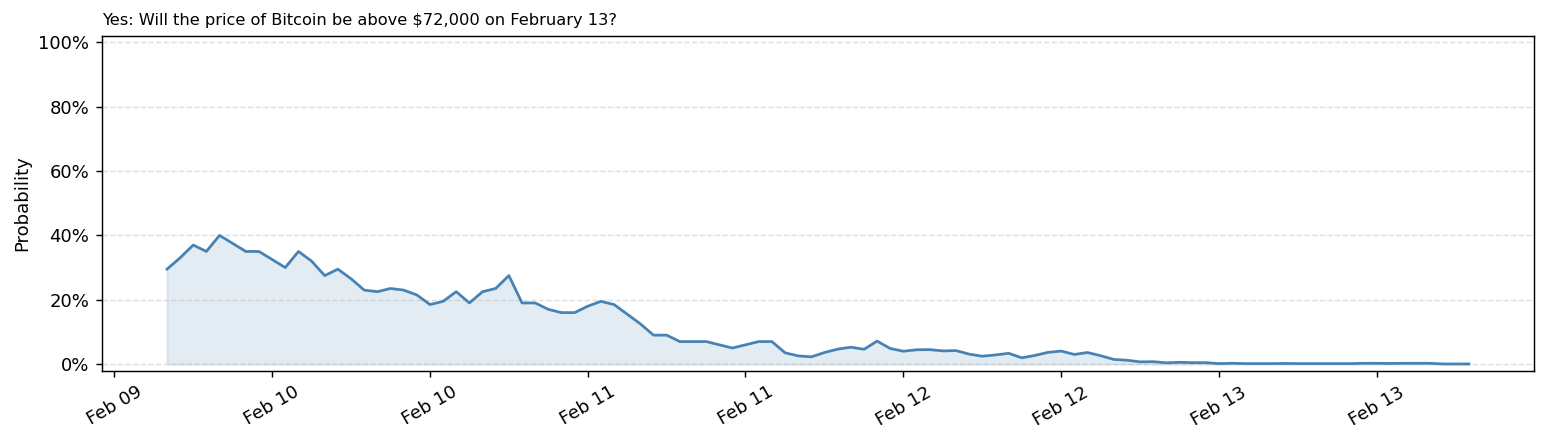

In [5]:
groups = list(df.groupby('slug'))
n = len(groups)

fig, axes = plt.subplots(n, 1, figsize=(12, 3.5 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, (slug, grp) in zip(axes, groups):
    grp = grp.sort_values('timestamp')
    outcome = grp['outcome'].iloc[0]
    question = grp['question'].iloc[0]

    ax.plot(grp['timestamp'], grp['price'], linewidth=1.5, color='steelblue')
    ax.fill_between(grp['timestamp'], grp['price'], alpha=0.15, color='steelblue')

    ax.set_ylim(-0.02, 1.02)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylabel('Probability')

    # Wrap long questions
    import textwrap
    title = textwrap.fill(f"{outcome}: {question}", width=90)
    ax.set_title(title, fontsize=9, loc='left')

plt.tight_layout()
plt.show()

## 5. Overlay comparison — normalized to same time axis
Useful when markets have different durations.

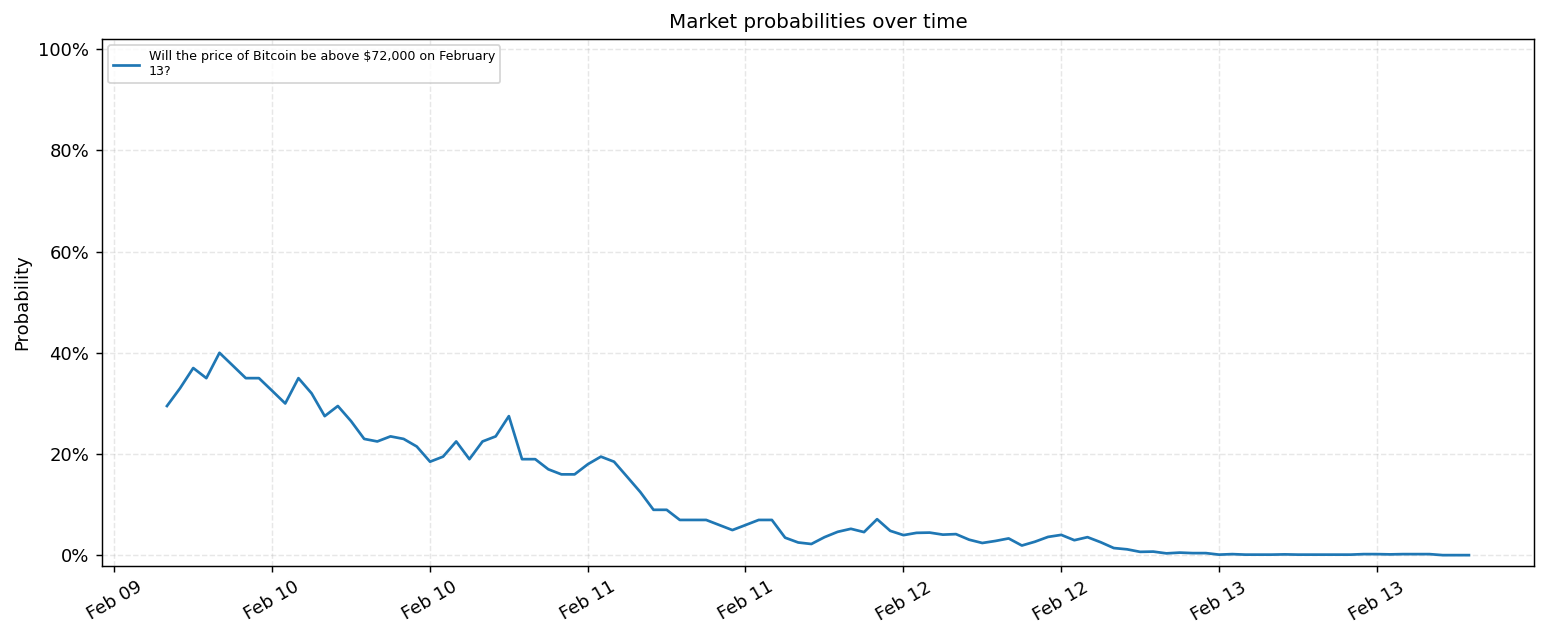

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

for slug, grp in df.groupby('slug'):
    grp = grp.sort_values('timestamp')
    label = textwrap.fill(grp['question'].iloc[0], width=55)
    ax.plot(grp['timestamp'], grp['price'], linewidth=1.5, label=label)

ax.set_ylim(-0.02, 1.02)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.tick_params(axis='x', rotation=30)
ax.grid(linestyle='--', alpha=0.3)
ax.set_ylabel('Probability')
ax.set_title('Market probabilities over time', fontsize=11)
ax.legend(fontsize=7, loc='upper left', framealpha=0.8)

plt.tight_layout()
plt.show()

## 6. Summary statistics

In [7]:
stats = (
    df.groupby(['question', 'outcome'])['price']
    .agg(['count', 'first', 'last', 'min', 'max', 'std'])
    .rename(columns={'count': 'n_points', 'first': 'price_start', 'last': 'price_end',
                     'min': 'price_min', 'max': 'price_max', 'std': 'volatility'})
    .round(3)
    .sort_values('n_points', ascending=False)
)
stats

,,n_points,price_start,price_end,price_min,price_max,volatility
question,outcome,,,,,,
"Will the price of Bitcoin be above $72,000 on February 13?",Yes,100,0.295,0.0,0.0,0.4,0.12
